### Measures of Dispersion / Variability (Spread)

- While central tendency gives us the center of a dataset, **measures of dispersion** describe how spread out or clustered the data points are around that center.

- Below are clear, naive examples covering the primary measures of dispersion, complete with mathematical formulas, notation pronunciations, and Python implementation comparisons across **Plain Python**, **Standard Library `statistics`**, and **`NumPy`** / **`SciPy`**.
---
---

### Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics


# set style for plots
plt.style.use('seaborn_v0_8_white' if 'seaborn_v0_8_white' in plt.style.available else 'default')
plt.rcParams["figure.dpi"] = 100 # set the dpi
# seed 
np.random.seed(42)


--- 
## 1. Range (Spread from Minimum to Maximum)

* **What it does:** Measures the total span between the largest and smallest observations.
* **Mathematical Notation:**
  $$R = x_{\max} - x_{\min}$$
  *Where:*
  * $R$ (*R*): Range
  * $x_{\max}$ (*x max*): Maximum value in the dataset
  * $x_{\min}$ (*x min*): Minimum value in the dataset
* **Naive Example:** Daily high temperatures over a week: `[18, 20, 22, 25, 30]` ($x_{\min} = 18, x_{\max} = 30$).
  $$R = 30 - 18 = 12^\circ\text{C}$$
* **When to use:** For quick, high-level checks where simple boundaries are needed.

Plain Python calculation:      12°C
NumPy (np.max - np.min):        12°C
NumPy (np.ptp):                12°C


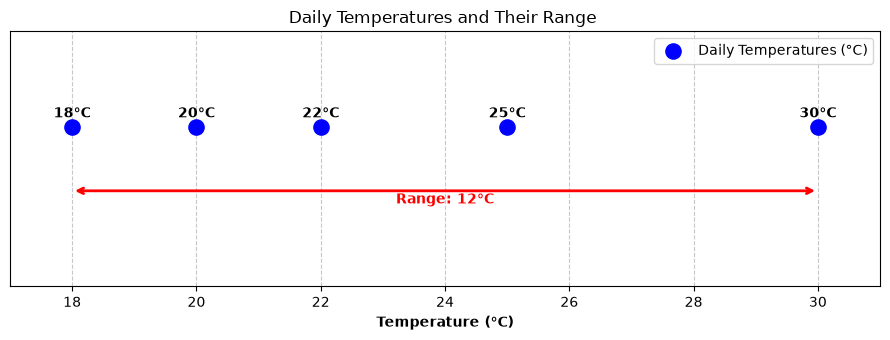

In [4]:
# 1. Range Example
temperatures = [18, 20, 22, 25, 30]
min_val,max_val = min(temperatures), max(temperatures)
range_python = max(temperatures) - min(temperatures) # Plain Python


range_np_minmax = np.max(temperatures) - np.min(temperatures) # NumPy - Method A: Expressive Min/Max (Recommended in modern NumPy)

# NumPy - Method B: Peak-to-Peak function
range_np_ptp = np.ptp(temperatures)  # 'ptp' stands for peak-to-peak

print(f"Plain Python calculation:      {range_python}°C")
print(f"NumPy (np.max - np.min):        {range_np_minmax}°C")
print(f"NumPy (np.ptp):                {range_np_ptp}°C")


# generate visualization for the range
plt.figure(figsize=(9, 3.5))
plt.scatter(temperatures, [1]*len(temperatures), color='blue', s=120, zorder=2, label="Daily Temperatures (°C)")
# Each point Annotation
for i, temp in enumerate(temperatures):
    plt.text(temp, 1.02, f"{temp}°C", ha='center', va='bottom', fontsize=10,fontweight='bold')

# parameters used in annotate
# arrowprops : dictionary of properties for the arrow
# arrowstyle="<->" creates a double-headed arrow
# lw=2 sets the line width of the arrow to 2
plt.annotate("",xy=(min_val, 0.8), xytext=(max_val, 0.8),
             arrowprops=dict(arrowstyle="<->", color='red', lw=2))
plt.text((min_val + max_val) / 2, 0.75, f"Range: {range_python}°C", ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

plt.ylim(0.5, 1.3)
plt.xlim(min(temperatures) - 1, max(temperatures) + 1)
plt.yticks([])
plt.xlabel("Temperature (°C)",fontweight='bold')
plt.title("Daily Temperatures and Their Range ")
plt.grid(True, linestyle='--', alpha=0.7,axis='x')
plt.legend()
plt.tight_layout() # Adjust subplots to fit into figure area.
plt.show()


--- 
## 2. Interquartile Range (IQR - Middle 50% Spread)

* **What it does:** Measures the spread of the middle 50% of data, ignoring extreme top and bottom tail values.
* **Mathematical Notation:**
  $$\text{IQR} = Q_3 - Q_1$$
  *Where:*
  * $\text{IQR}$ (*I-Q-R*): Interquartile Range
  * $Q_1$ (*Q one*): 25th percentile (first quartile)
  * $Q_3$ (*Q three*): 75th percentile (third quartile)
* **Naive Example:** Exam scores: `[10, 50, 60, 70, 80, 85, 100]`. $Q_1 = 50$ and $Q_3 = 85$.
  $$\text{IQR} = 85 - 50 = 35 \text{ marks}$$
* **When to use:** When data has heavy outliers or skewness (e.g., house prices, incomes).

In [5]:
# ---------------------------------------------------------
# 1. Core / Pure Python (From Scratch via Linear Interpolation)
# ---------------------------------------------------------
def get_percentile_linear(data, percentile):
    """Calculates percentile using linear interpolation (NumPy default equivalent)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Fractional index position
    index = (percentile / 100) * (n - 1)
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

def get_percentile_weibull(data, percentile):
    """Calculates percentile using the Weibull method (similar to Excel's PERCENTILE.INC)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Weibull formula for percentile rank
    rank = (percentile / 100) * (n + 1)
    index = rank - 1 # why -1 ? Because the formula calculates a 1-based index, but Python uses 0-based indexing.
    if index < 0:
        return sorted_data[0]
    elif index >= n - 1:
        return sorted_data[-1]
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

scores = [10, 50, 60, 70, 80, 85, 100]

# Example usage
q1_linear = get_percentile_linear(scores, 25)
q3_linear = get_percentile_linear(scores, 75)
iqr_linear = q3_linear - q1_linear

# exclusive corresponds to the linear method in the statistics module
q1_stats_linear,_,q3_stats_linear = statistics.quantiles(scores, n=4, method='exclusive')
iqr_stats_linear = q3_stats_linear - q1_stats_linear

# in statistics module, the 'inclusive' method corresponds to the Weibull method

# using statistics.quantiles with the Weibull method
q1_stats_weibull,_,q3_stats_weibull = statistics.quantiles(scores, n=4, method='inclusive')
iqr_stats_weibull = q3_stats_weibull - q1_stats_weibull

# using numpy np.percentile (linear interpolation)

q1_np_linear = np.percentile(scores, 25, method='linear')
q3_np_linear = np.percentile(scores, 75, method='linear')
iqr_np_linear = q3_np_linear - q1_np_linear

# using numpy np.percentile (Weibull method)
q1_np_weibull = np.percentile(scores, 25, method='weibull')
q3_np_weibull = np.percentile(scores, 75, method='weibull')
iqr_np_weibull = q3_np_weibull - q1_np_weibull


q1_weibull = get_percentile_weibull(scores, 25)
q3_weibull = get_percentile_weibull(scores, 75)
iqr_weibull = q3_weibull - q1_weibull


# let us print All as a table using string formatiing
print(f"{'Method':<35}{'Q1':<10}{'Q3':<10}{'IQR':<10}")
print(f"{'-'*65}")
print(f"{'Linear (custom function)':<35}{q1_linear:<10}{q3_linear:<10}{iqr_linear:<10}")
print(f"{'Linear (statistics module)':<35}{q1_stats_linear:<10}{q3_stats_linear:<10}{iqr_stats_linear:<10}")
print(f"{'Weibull (statistics module)':<35}{q1_stats_weibull:<10}{q3_stats_weibull:<10}{iqr_stats_weibull:<10}")
print(f"{'Linear (numpy)':<35}{q1_np_linear:<10}{q3_np_linear:<10}{iqr_np_linear:<10}")
print(f"{'Weibull (numpy)':<35}{q1_np_weibull:<10}{q3_np_weibull:<10}{iqr_np_weibull:<10}")
print(f"{'Weibull (custom function)':<35}{q1_weibull:<10}{q3_weibull:<10}{iqr_weibull:<10}")




Method                             Q1        Q3        IQR       
-----------------------------------------------------------------
Linear (custom function)           55.0      82.5      27.5      
Linear (statistics module)         50.0      85.0      35.0      
Weibull (statistics module)        55.0      82.5      27.5      
Linear (numpy)                     55.0      82.5      27.5      
Weibull (numpy)                    50.0      85.0      35.0      
Weibull (custom function)          50.0      85.0      35.0      


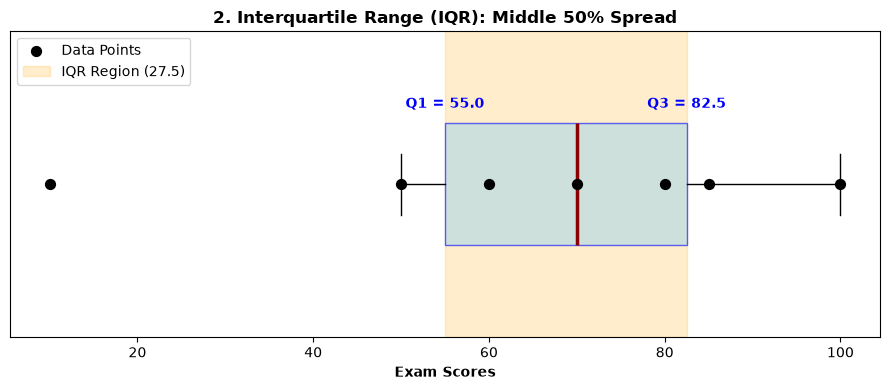

In [6]:
scores = [10, 50, 60, 70, 80, 85, 100]
q1 = np.percentile(scores, 25, method='linear')
q3 = np.percentile(scores, 75, method='linear')
iqr = q3 - q1

fig, ax = plt.subplots(figsize=(9, 4))

# Plot horizontal boxplot
bp = ax.boxplot(scores, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))

# Plot raw points
ax.scatter(scores, [1] * len(scores), color='black', zorder=4, label='Data Points', s=50)

# Highlight IQR span
ax.axvspan(q1, q3, color='orange', alpha=0.2, label=f'IQR Region ({iqr:.1f})')

# Annotate Q1 and Q3
ax.text(q1, 1.25, f'Q1 = {q1:.1f}', ha='center', color='blue', fontweight='bold')
ax.text(q3, 1.25, f'Q3 = {q3:.1f}', ha='center', color='blue', fontweight='bold')

ax.set_yticks([])
ax.set_xlabel('Exam Scores', fontweight='bold')
ax.set_title('2. Interquartile Range (IQR): Middle 50% Spread', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

--- 
## 3. Sample Variance (Average Squared Deviations)

* **What it does:** Measures how far points deviate from the mean on average, squared so positive and negative differences do not cancel out.
* **Mathematical Notation:**
  $$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$
  *Where:*
  * $s^2$ (*s squared*): Sample variance
  * $n-1$ (*n minus one*): Bessel's correction for sample bias
  * $x_i$ (*x sub i*): i-th observation
  * $\bar{x}$ (*x-bar*): Sample mean
  * $\sum$ (*capital Sigma*): Summation operator
* **Naive Example:** Heights of 3 plants in cm: `[10, 20, 30]` ($n = 3$, $\bar{x} = 20$). Deviations are $(-10, 0, 10)$, squared deviations are $(100, 0, 100)$.
  $$s^2 = \frac{100 + 0 + 100}{3 - 1} = \frac{200}{2} = 100 \text{ cm}^2$$
* **When to use:** Foundation for inferential statistics and risk modeling (units are squared).

In [7]:
# 3. Sample Variance Example
plants = [10, 20, 30]

# Plain Python
mean_val = sum(plants) / len(plants)
var_python = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)

# Standard Library (statistics)
var_stats = statistics.variance(plants)

# use numpy for variance
var_np = np.var(plants,ddof=1) # ddof =1 Bessel's correction

print(f"Plain Python calculation:  {var_python:.1f} cm²")
print(f"statistics.variance():      {var_stats:.1f} cm²")
print(f"np.var(ddof=1):            {var_np:.1f} cm²")



Plain Python calculation:  100.0 cm²
statistics.variance():      100.0 cm²
np.var(ddof=1):            100.0 cm²


--- 
#### 4. Sample Standard Deviation (Spread in Original Units)

* **What it does:** Converts variance back into original measurement units by taking the square root.
* **Mathematical Notation:**
  $$s = \sqrt{s^2} = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$
  *Where:*
  * $s$ (*s*): Sample standard deviation
  * $s^2$ (*s squared*): Sample variance
  * $\sqrt{\cdot}$ (*square root*): Square root operator
* **Naive Example:** Using plant heights `[10, 20, 30]` with sample variance $s^2 = 100\text{ cm}^2$:
  $$s = \sqrt{100} = 10\text{ cm}$$
* **When to use:** Primary metric for describing spread in standard units alongside the mean.

In [8]:
# 4. Sample Standard Deviation Example
plants = [10, 20, 30]

# Plain Python
mean_val = sum(plants) / len(plants)
var_val = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)
std_python = math.sqrt(var_val)

# Standard Library (statistics)
std_stats = statistics.stdev(plants)

# NumPy Library (ddof=1 specifies sample standard deviation)
std_np = np.std(plants, ddof=1)

print(f"Plain Python calculation:  {std_python:.1f} cm")
print(f"statistics.stdev():        {std_stats:.1f} cm")
print(f"np.std(ddof=1):            {std_np:.1f} cm")


Plain Python calculation:  10.0 cm
statistics.stdev():        10.0 cm
np.std(ddof=1):            10.0 cm


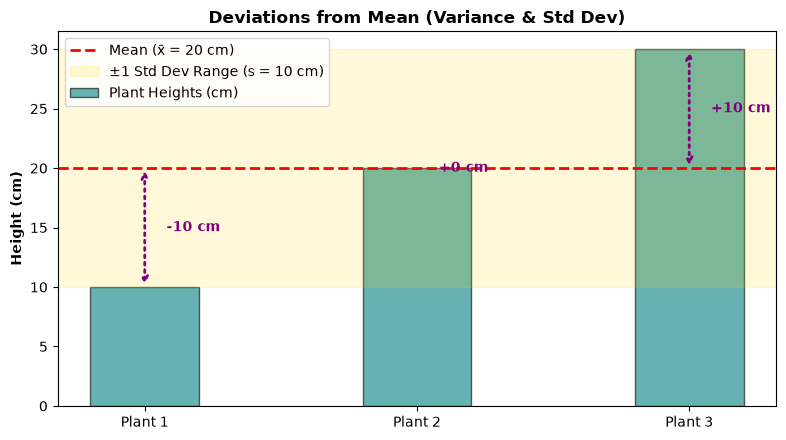

In [ ]:
plants = [10, 20, 30]
mean_val = np.mean(plants)
std_val = np.std(plants, ddof=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
x_indices = np.arange(1, len(plants) + 1)
bars = ax.bar(x_indices, plants, width=0.4, color='teal', alpha=0.6, label='Plant Heights (cm)', edgecolor='black')

# Draw Mean Line
ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean (x̄ = {mean_val:.0f} cm)')

# Draw deviation vectors
for idx, h in zip(x_indices, plants):
    ax.annotate('', xy=(idx, h), xytext=(idx, mean_val),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2, linestyle=':'))
    dev = h - mean_val
    ax.text(idx + 0.08, (h + mean_val) / 2, f'{dev:+0.0f} cm', color='purple', fontweight='bold', va='center')


# Highlight ±1 Std Dev Band
ax.axhspan(mean_val - std_val, mean_val + std_val, color='gold', alpha=0.15, label=f'±1 Std Dev Range (s = {std_val:.0f} cm)')

ax.set_xticks(x_indices)
ax.set_xticklabels([f'Plant {i}' for i in x_indices])
ax.set_ylabel('Height (cm)', fontweight='bold')
ax.set_title('Deviations from Mean (Variance & Std Dev)', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()
